# RAFT (Retrieval Augmented Fine-Tuning) with Unsloth & LoRA

Notebook ini dibuat untuk melakukan fine-tuning model LLM menggunakan dataset RAFT (`raft_dataset_finalv3.jsonl`) dengan teknik LoRA (Low-Rank Adaptation) dan *library* Unsloth agar proses *training* jauh lebih cepat dan hemat memori.

In [6]:
# %%capture
# !pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
# !pip install --no-deps xformers trl peft accelerate bitsandbytes datasets

### STEP 1: Cek Lingkungan (GPU & Library)

In [11]:
import torch
import transformers
import trl

print("=" * 60)
print("CEK LINGKUNGAN")
print("=" * 60)
print(f"PyTorch version   : {torch.__version__}")
print(f"Transformers ver  : {transformers.__version__}")
print(f"TRL version       : {trl.__version__}")
print(f"CUDA available    : {torch.cuda.is_available()}")
print(f"GPU count         : {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}            : {torch.cuda.get_device_name(i)}")
        props = torch.cuda.get_device_properties(i)
        print(f"  Total memory    : {props.total_memory / 1024**3:.2f} GB")
        print(f"  Compute cap     : {props.major}.{props.minor}")
print("=" * 60)

assert torch.cuda.is_available(), "CUDA tidak tersedia! Pastikan GPU terdeteksi."

CEK LINGKUNGAN
PyTorch version   : 2.11.0+cu128
Transformers ver  : 5.5.0
TRL version       : 0.24.0
CUDA available    : True
GPU count         : 1
GPU 0            : NVIDIA B200
  Total memory    : 178.36 GB
  Compute cap     : 10.0


## 1. Load Model dengan Unsloth & Konfigurasi LoRA
Kita akan menggunakan model `Llama-3-8B-Instruct` sebagai *base model*. Unsloth menyediakan model dalam format 4-bit secara bawaan untuk penghematan memori.

In [2]:
from unsloth import FastLanguageModel
import torch

MODEL_NAME = "../model/Meta-Llama-3.1-8B-Instruct"
MAX_SEQ_LENGTH = 4096
DTYPE = None
LOAD_IN_4BIT = False

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=DTYPE,
    load_in_4bit=LOAD_IN_4BIT,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/workspace/.venv/lib/python3.10/site-packages/unsloth/__init__.py:153: UserWarning: WARNING: Unsloth should be imported before [trl, transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA B200. Num GPUs = 1. Max memory: 178.361 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 10.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 291/291 [00:02<00:00, 110.18it/s]
Unsloth: Will load ../model/Meta-Llama-3.1-8B-Instruct as a legacy tokenizer.


../model/Meta-Llama-3.1-8B-Instruct does not have a padding token! Will use pad_token = <|finetune_right_pad_id|>.


## LORA

In [3]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)

print("Model + LoRA berhasil dimuat.")

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.6.9 patched 32 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Model + LoRA berhasil dimuat.


## 2. Persiapan & Formatting Dataset RAFT
Di sini kita akan memproses format dataset dan menyatukannya dalam struktur *prompt* instruksi. Model akan diajarkan untuk merangkai `<thought>` (Chain of Thought) terlebih dahulu untuk memilah dokumen distraktor sebelum memberikan jawaban akhir.

In [4]:
from datasets import load_dataset, concatenate_datasets
import json
import random
import re

# ==========================================================
# LOAD DATASET
# ==========================================================
dataset_path_1 = "../data/dataset/raft_dataset_finalv5_corrected.jsonl"

try:
    ds1 = load_dataset("json", data_files=dataset_path_1, split="train")

    cols_to_remove = ["metadata_extra", "validation"]
    ds1 = ds1.remove_columns([c for c in cols_to_remove if c in ds1.column_names])

    dataset = concatenate_datasets([ds1])
    print(f"Berhasil dimuat! Total data awal: {len(dataset)} baris.")

except Exception as e:
    print(f"Error saat load dataset: {e}")
    raise


# ==========================================================
# PROMPT HYBRID: CONTEXT SELECTION + THOUGHT + FINAL ANSWER
# ==========================================================
raft_prompt = """<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Anda adalah asisten AI ahli dalam menjawab pertanyaan berdasarkan dokumen hukum dan peraturan desa.

Tugas Anda:
1. Periksa semua dokumen referensi yang diberikan.
2. Pilih hanya dokumen yang benar-benar menjawab pertanyaan.
3. Cocokkan secara teliti nama desa, nomor dan tahun peraturan, pasal, ayat, serta isi ketentuan yang ditanyakan.
4. Abaikan dokumen yang tidak relevan, salah desa, salah peraturan, salah pasal/ayat, atau hanya mirip topiknya.
5. Jika beberapa dokumen tampak serupa tetapi rincian isinya berbeda, jangan menggabungkan isinya.
6. Jangan menambah rincian yang tidak tertulis dalam dokumen yang dipilih.
7. Jika tidak ada dokumen valid, katakan bahwa informasi tidak ditemukan.
8. Jawaban akhir hanya boleh berdasarkan dokumen yang dipilih.

Format jawaban HARUS seperti ini:

KONTEKS_DIPILIH: [id dokumen]
KONTEKS_DITOLAK: [id dokumen]

<thought>
alasan memilih atau menolak dokumen
</thought>

JAWABAN:
<jawaban akhir>

<|eot_id|><|start_header_id|>user<|end_header_id|>

Pertanyaan: {instruction}

Dokumen Referensi:
{documents}

<|eot_id|><|start_header_id|>assistant<|end_header_id|>

KONTEKS_DIPILIH: {selected_doc_ids}
KONTEKS_DITOLAK: {rejected_doc_ids}

<thought>
{thought_process}
</thought>

JAWABAN:
{completion}"""

EOS_TOKEN = tokenizer.eos_token


# ==========================================================
# HELPER: FORMAT THOUGHT PROCESS
# ==========================================================
def format_thought_process(tp):
    """
    thought_process di dataset berbentuk dict:
    {
      "document_analysis": [...],
      "summary": "..."
    }
    Ubah menjadi string reasoning yang rapi.
    """
    if tp is None:
        return "Tidak ada analisis dokumen."

    if isinstance(tp, str):
        return tp.strip() if tp.strip() else "Tidak ada analisis dokumen."

    if isinstance(tp, dict):
        lines = []

        doc_analysis = tp.get("document_analysis", [])
        if isinstance(doc_analysis, list):
            for item in doc_analysis:
                doc_id = item.get("document", "?")
                analysis = item.get("analysis", "").strip()
                if analysis:
                    lines.append(f"Dokumen {doc_id}: {analysis}")

        summary = tp.get("summary", "").strip()
        if summary:
            lines.append(f"Ringkasan: {summary}")

        text = "\n".join(lines).strip()
        return text if text else "Tidak ada analisis dokumen."

    return str(tp)


# ==========================================================
# HELPER: EXTRACT SELECTED / REJECTED DOC IDS
# ==========================================================
# PERBAIKAN CRITICAL #1 & #2:
#  - Label KONTEKS_DIPILIH sekarang diturunkan dari TUMPANG_TINDIH (overlap)
#    leksikal antara `completion` (jawaban) dan masing-masing dokumen,
#    BUKAN lagi dari kata kunci rapuh di `thought_process`.
#  - Kasus "tidak ada dokumen oracle" (semua distraktor) dideteksi dari
#    jawaban penolakan, lalu menghasilkan KONTEKS_DIPILIH KOSONG agar model
#    belajar menolak (inti dari RAFT).
# ==========================================================
_STOPWORDS = set(
    "dan atau dari pada ke dalam dengan yang untuk adalah sebagai oleh ini itu "
    "di per dike desa nomor tahun pasal ayat tentang pada oleh dengan".split()
)


def _tokenize(text):
    """Tokenisasi sederhana: alphanumeric, buang stopword & token pendek."""
    if not text:
        return set()
    toks = re.findall(r"[a-z0-9]+", text.lower())
    return {t for t in toks if t not in _STOPWORDS and len(t) > 2}


_REJECT_PATTERNS = [
    r"informasi (tidak|belum) ditemukan",
    r"tidak (ditemukan|ada|terdapat) (informasi|jawaban|dokumen)",
    r"tidak (dapat|bisa) (dijawab|ditemukan)",
    r"jawaban (tidak|belum) (ditemukan|ada)",
]


def _is_rejection(completion):
    """True bila jawaban merupakan penolakan (tidak ada dokumen oracle)."""
    c = (completion or "").lower()
    return any(re.search(p, c) for p in _REJECT_PATTERNS)


def extract_selected_and_rejected_ids(
    completion,
    documents,
    total_docs,
    rel_threshold=0.6,
    floor_threshold=0.20,
):
    """
    Menentukan dokumen yang dipilih (selected) dan ditolak (rejected).

    - Jika `completion` adalah jawaban penolakan -> selected = [] (kosong),
      artinya model diajarkan untuk MENOLAK ketika tidak ada dokumen relevan.
    - Jika tidak, pilih dokumen yang kontennya paling tumpang-tindih dengan
      jawaban (relative overlap >= rel_threshold DAN absolute >= floor_threshold).
    """
    # Kasus penolakan / semua distraktor
    if _is_rejection(completion):
        return [], list(range(1, total_docs + 1))

    comp_tokens = _tokenize(completion)
    if not comp_tokens:
        # Jawaban tidak bisa di-tokenize -> anggap tidak ada yang relevan
        return [], list(range(1, total_docs + 1))

    coverages = []
    for doc in documents:
        doc_tokens = _tokenize(doc)
        cov = len(comp_tokens & doc_tokens) / len(comp_tokens)
        coverages.append(cov)

    max_cov = max(coverages) if coverages else 0.0
    selected = [
        i + 1
        for i, cov in enumerate(coverages)
        if cov >= rel_threshold * max_cov and cov >= floor_threshold
    ]

    # Safety net: bila tidak ada yang lolos (seharusnya jarang),
    # pilih dokumen dengan overlap tertinggi agar tidak kosong secara tidak sengaja.

    # if not selected and coverages:
    #     top = max(range(len(coverages)), key=lambda i: coverages[i])
    #     selected = [top + 1]

    if not selected:
         return [], list(range(1, total_docs + 1))


    selected = sorted(set(selected))
    rejected = [i for i in range(1, total_docs + 1) if i not in selected]
    return selected, rejected


# ==========================================================
# FORMAT DATASET MENJADI TEXT TRAINING
# ==========================================================
def formatting_prompts_func(examples):
    texts = []

    for instruction, docs, thought, completion, selected, rejected in zip(
        examples["instruction"],
        examples["documents"],
        examples["thought_process"],
        examples["completion"],
        examples["selected_doc_ids"],
        examples["rejected_doc_ids"],
    ):
        formatted_docs = "\n\n".join(
            f"[{i}] {doc}" for i, doc in enumerate(docs, start=1)
        )

        selected_str = ", ".join(map(str, selected)) if selected else "-"
        rejected_str = ", ".join(map(str, rejected)) if rejected else "-"

        text = raft_prompt.format(
            instruction=instruction.strip(),
            documents=formatted_docs.strip(),
            selected_doc_ids=selected_str,
            rejected_doc_ids=rejected_str,
            thought_process=format_thought_process(thought),
            completion=completion.strip(),
        ) + tokenizer.eos_token

        texts.append(text)

    return {"text": texts}


# ==========================================================
# MAP DATASET
# ==========================================================
dataset = dataset.map(
    formatting_prompts_func,
    batched=True,
    remove_columns=dataset.column_names
)

print(f"\nDataset setelah formatting: {len(dataset)}")
print("\n--- Contoh Hasil Format Prompt Baris Pertama ---\n")
print(dataset[0]["text"][:5000])


# ==========================================================
# SPLIT 80:20 TRAIN / VALIDATION
# ==========================================================
split_dataset = dataset.train_test_split(
    test_size=0.2,
    seed=3407,
    shuffle=True
)

train_dataset = split_dataset["train"]
eval_dataset  = split_dataset["test"]

print("\n=== HASIL SPLIT DATASET ===")
print(f"Train size : {len(train_dataset)}")
print(f"Valid size : {len(eval_dataset)}")

Berhasil dimuat! Total data awal: 425 baris.

Dataset setelah formatting: 425

--- Contoh Hasil Format Prompt Baris Pertama ---

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Anda adalah asisten AI ahli dalam menjawab pertanyaan berdasarkan dokumen hukum dan peraturan desa.

Tugas Anda:
1. Periksa semua dokumen referensi yang diberikan.
2. Pilih hanya dokumen yang benar-benar menjawab pertanyaan.
3. Cocokkan secara teliti nama desa, nomor dan tahun peraturan, pasal, ayat, serta isi ketentuan yang ditanyakan.
4. Abaikan dokumen yang tidak relevan, salah desa, salah peraturan, salah pasal/ayat, atau hanya mirip topiknya.
5. Jika beberapa dokumen tampak serupa tetapi rincian isinya berbeda, jangan menggabungkan isinya.
6. Jangan menambah rincian yang tidak tertulis dalam dokumen yang dipilih.
7. Jika tidak ada dokumen valid, katakan bahwa informasi tidak ditemukan.
8. Jawaban akhir hanya boleh berdasarkan dokumen yang dipilih.

Format jawaban HARUS seperti ini:

KONTEKS_DIP

## 3. Training Menggunakan SFTTrainer dari TRL

In [5]:
from trl import SFTTrainer, SFTConfig
from unsloth import is_bfloat16_supported
from unsloth.chat_templates import train_on_responses_only
import os
import json

sft_config = SFTConfig(
    dataset_text_field="text",
    dataset_num_proc=1,
    packing=False,

    per_device_train_batch_size=4,
    gradient_accumulation_steps=8,
    num_train_epochs=5,

    learning_rate=5e-5,
    warmup_ratio=0.05,
    weight_decay=0.01,

    fp16=not is_bfloat16_supported(),
    bf16=is_bfloat16_supported(),

    logging_steps=10,
    optim="adamw_8bit",
    lr_scheduler_type="linear",
    seed=3407,

    output_dir="../model/outputs_lora_V4",
    logging_dir="../model/outputs_lora_V4/tensorboard_logs_V4",
    report_to="tensorboard",

    eval_strategy="epoch",        
    save_strategy="epoch",          
    load_best_model_at_end=True,    
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    save_total_limit=3,
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=sft_config,
    dataset_text_field="text",
    max_seq_length=4096,
)

trainer = train_on_responses_only(
    trainer,
    instruction_part="<|start_header_id|>user<|end_header_id|>\n\n",
    response_part="<|start_header_id|>assistant<|end_header_id|>\n\n",
)

print("\n>>> Memulai training...")
trainer_stats = trainer.train()

print("\nTraining selesai.")
print(trainer_stats)

trainer.save_state()

# Simpan metrics manual juga biar gampang dibaca
OUTPUT_DIR = "../model/outputs_lora_V4"
os.makedirs(OUTPUT_DIR, exist_ok=True)
metrics_path = os.path.join(OUTPUT_DIR, "train_metrics.json")
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(trainer.state.log_history, f, ensure_ascii=False, indent=2)

print(f"Metrics training disimpan ke: {metrics_path}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009}.



>>> Memulai training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 340 | Num Epochs = 5 | Total steps = 55
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 8 x 1) = 32
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Epoch,Training Loss,Validation Loss
1,0.402116,0.180956
2,0.134374,0.092837
3,0.084221,0.080838
4,0.071289,0.077050
5,0.065325,0.075712


/workspace/.venv/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/workspace/.venv/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/workspace/.venv/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Pleas


Training selesai.
TrainOutput(global_step=55, training_loss=0.14360366355289111, metrics={'train_runtime': 593.972, 'train_samples_per_second': 2.862, 'train_steps_per_second': 0.093, 'total_flos': 1.3316568827707392e+17, 'train_loss': 0.14360366355289111, 'epoch': 5.0})
Metrics training disimpan ke: ../model/outputs_lora_V4/train_metrics.json


## Plot diagram train loss vs eval loss

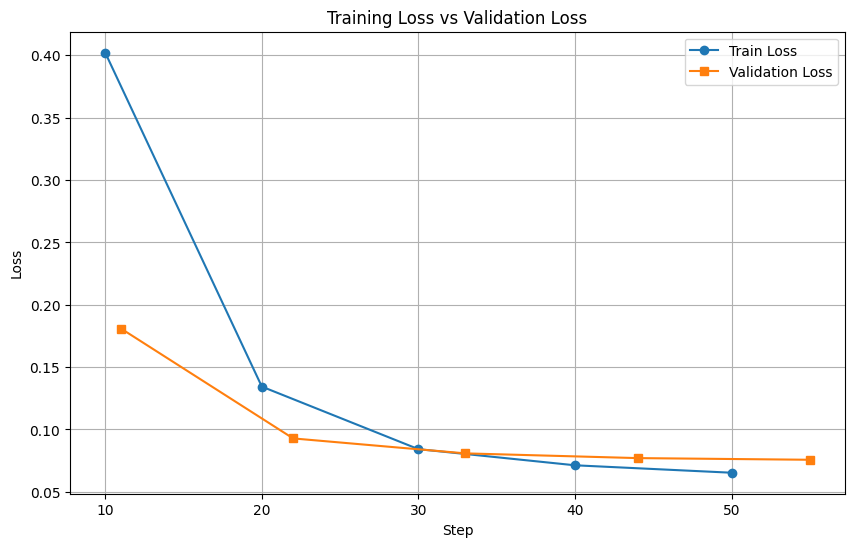

Jumlah titik train loss : 5
Jumlah titik eval loss  : 5


In [6]:
import os
import json
import matplotlib.pyplot as plt

OUTPUT_DIR = "../model/outputs_lora_V4"
metrics_path = os.path.join(OUTPUT_DIR, "train_metrics.json")

with open(metrics_path, "r", encoding="utf-8") as f:
    log_history = json.load(f)

train_steps = []
train_losses = []

eval_steps = []
eval_losses = []

for log in log_history:
    if "loss" in log and "eval_loss" not in log:
        train_steps.append(log.get("step"))
        train_losses.append(log["loss"])

    if "eval_loss" in log:
        eval_steps.append(log.get("step"))
        eval_losses.append(log["eval_loss"])

plt.figure(figsize=(10, 6))
if train_steps:
    plt.plot(train_steps, train_losses, marker="o", label="Train Loss")
if eval_steps:
    plt.plot(eval_steps, eval_losses, marker="s", label="Validation Loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

print("Jumlah titik train loss :", len(train_losses))
print("Jumlah titik eval loss  :", len(eval_losses))

## Ringkasan hasil fine-tune terbaik

In [7]:
import os
import json
import pandas as pd

OUTPUT_DIR = "../model/outputs_lora_V4"

with open(metrics_path, "r", encoding="utf-8") as f:
    log_history = json.load(f)

rows = []
for log in log_history:
    row = {
        "step": log.get("step"),
        "epoch": log.get("epoch"),
        "loss": log.get("loss"),
        "eval_loss": log.get("eval_loss"),
        "learning_rate": log.get("learning_rate"),
    }
    rows.append(row)

df_metrics = pd.DataFrame(rows)
display(df_metrics.tail(20))

eval_rows = df_metrics[df_metrics["eval_loss"].notna()].copy()

if len(eval_rows) > 0:
    best_row = eval_rows.loc[eval_rows["eval_loss"].idxmin()]
    print("=== HASIL VALIDASI TERBAIK ===")
    print(f"Step terbaik      : {best_row['step']}")
    print(f"Epoch terbaik     : {best_row['epoch']}")
    print(f"Best eval_loss    : {best_row['eval_loss']}")
else:
    print("Belum ada eval_loss yang tercatat.")

,step,epoch,loss,eval_loss,learning_rate
0,10,0.941176,0.402116,NaN,0.000044
1,11,1.000000,NaN,0.180956,NaN
2,20,1.847059,0.134374,NaN,0.000035
3,22,2.000000,NaN,0.092837,NaN
4,30,2.752941,0.084221,NaN,0.000025
5,33,3.000000,NaN,0.080838,NaN
6,40,3.658824,0.071289,NaN,0.000015
7,44,4.000000,NaN,0.077050,NaN
8,50,4.564706,0.065325,NaN,0.000006
9,55,5.000000,NaN,0.075712,NaN


=== HASIL VALIDASI TERBAIK ===
Step terbaik      : 55.0
Epoch terbaik     : 5.0
Best eval_loss    : 0.07571196556091309


In [8]:
metrics = trainer_stats.metrics

print("=" * 60)
print("RINGKASAN TRAINING")
print("=" * 60)
for k, v in metrics.items():
    print(f"{k}: {v}")

print("=" * 60)
print(f"Best checkpoint : {trainer.state.best_model_checkpoint}")
print(f"Best eval loss  : {trainer.state.best_metric}")
print("=" * 60)

RINGKASAN TRAINING
train_runtime: 593.972
train_samples_per_second: 2.862
train_steps_per_second: 0.093
total_flos: 1.3316568827707392e+17
train_loss: 0.14360366355289111
epoch: 5.0
Best checkpoint : ../model/outputs_lora_V4/checkpoint-55
Best eval loss  : 0.07571196556091309


## DEMO INFERENCE

In [9]:
# FastLanguageModel.for_inference(model)

# test_instruction = "Siapa saja unsur masyarakat yang diundang dan harus hadir dalam Musyawarah Desa pemilihan kewenangan di Desa Cigentur?"
# test_docs = [
#     "unsur masyarakat  Musyawarah Desa pemilihan kewenangan di Desa cigentur dimaksud pada ayat (1) terdiri dari : a. perwakilan perangkat desa;\nb. anggota badan permusyawaratan desa (bpd);\nc. perwakilan kecamatan;\nd. perwakilan pengusaha lokal;\ne. ketua rukun warga (rw).",
# "unsur masyarakat sebagaimana dimaksud pada ayat (1) terdiri dari : a. tokoh agama;\nb. tokoh masyarakat;\nc. tokoh pendidik;\nd. perwakilan kelompok tani;\ne. perwakilan kelompok perajin;\nf. perwakilan kelompok perempuan;\ng. perwakilan kelompok pemerhati dan perlindungan anak; dan\nh. perwakilan kelompok masyarakat miskin."
# ]

# test_result = generate_answer_only(
#     model=model,
#     tokenizer=tokenizer,
#     instruction=test_instruction,
#     documents=test_docs,
#     max_new_tokens=2000
# )

# print("=== RAW GENERATION ===")
# print(test_result["raw_generation"])

# print("\n=== FINAL ANSWER ===")
# print(test_result["final_answer"])

## SAVE MODEL

In [10]:
ADAPTER_DIR = "/workspace/model/lora_adapter_raft_v4"
MERGED_DIR  = "/workspace/model/model_merged_raft_v4"

model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

# print(f"LoRA adapter disimpan ke: {ADAPTER_DIR}")

# model.save_pretrained_merged(
#     MERGED_DIR,
#     tokenizer,
#     save_method="merged_16bit"
# )

print(f"Merged model disimpan ke: {MERGED_DIR}")

Unsloth: Restored added_tokens_decoder metadata in /workspace/model/lora_adapter_raft_v4/tokenizer_config.json.


Merged model disimpan ke: /workspace/model/model_merged_raft_v4


In [ ]:
# Bersihkan model training dari VRAM SETELAH selesai save
del model
torch.cuda.empty_cache()
import gc
gc.collect()

print("Model training dibersihkan dari VRAM. Silakan load model inference di cell berikutnya.")

Model training dibersihkan dari VRAM. Silakan load model inference di cell berikutnya.


## load model

In [ ]:
from unsloth import FastLanguageModel
import torch

MODEL_DIR = "/workspace/model/model_merged_raft_v4"
MAX_SEQ_LENGTH = 4096
DTYPE = None
LOAD_IN_4BIT = False

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_DIR,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=DTYPE,
    load_in_4bit=LOAD_IN_4BIT,
)

FastLanguageModel.for_inference(model)

print("Model inference berhasil dimuat.")

==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA B200. Num GPUs = 1. Max memory: 178.361 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 10.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 291/291 [00:02<00:00, 138.57it/s]
The tokenizer you are loading from '/workspace/model/model_merged_raft_v4' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
The tokenizer you are loading from '/workspace/model/model_merged_raft_v4' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Unsloth: Will load /workspace/model/model_merged_raft_v4 as a legacy tokenizer.


Model inference berhasil dimuat.


## Promt template

In [ ]:
INFER_PROMPT = """<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Anda adalah asisten AI ahli dalam menjawab pertanyaan berdasarkan dokumen hukum dan peraturan desa.

Tugas Anda:
1. Periksa semua dokumen referensi yang diberikan.
2. Pilih hanya dokumen yang benar-benar menjawab pertanyaan.
3. Abaikan dokumen yang tidak relevan, salah pasal/ayat, atau hanya mirip topiknya.
4. Jika tidak ada dokumen yang valid, katakan bahwa informasi tidak ditemukan pada dokumen yang diberikan.
5. Jawaban akhir hanya boleh berdasarkan dokumen yang dipilih.

Format jawaban HARUS seperti ini:

KONTEKS_DIPILIH: [id dokumen]
KONTEKS_DITOLAK: [id dokumen]

<thought>
alasan memilih / menolak dokumen
</thought>

JAWABAN:
<jawaban akhir>

<|eot_id|><|start_header_id|>user<|end_header_id|>

Pertanyaan: {instruction}

Dokumen Referensi:
{documents}

<|eot_id|><|start_header_id|>assistant<|end_header_id|>
"""

In [ ]:
import torch
import re

def format_documents(docs):
    formatted = []
    for i, doc in enumerate(docs, start=1):
        formatted.append(f"[{i}] {doc}")
    return "\n\n".join(formatted)

In [ ]:

def generate_answer(instruction, docs, max_new_tokens=2048):
    documents_text = format_documents(docs)

    prompt = INFER_PROMPT.format(
        instruction=instruction.strip(),
        documents=documents_text.strip()
    )

    inputs = tokenizer(
        [prompt],
        return_tensors="pt",
        truncation=True,
        max_length=4096
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            use_cache=True,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=False)

    # ambil hanya bagian setelah prompt
    if decoded.startswith(prompt):
        result_text = decoded[len(prompt):].strip()
    else:
        prompt_text = tokenizer.decode(inputs["input_ids"][0], skip_special_tokens=False)
        result_text = decoded[len(prompt_text):].strip()

    # bersihkan token khusus
    result_text = (
        result_text
        .replace("<|eot_id|>", "")
        .replace("<|end_of_text|>", "")
        .strip()
    )

    return result_text, prompt

In [ ]:
instruction = "Sebutkan semua unsur masyarakat yang terdiri dari tokoh dan perwakilan kelompok sebagaimana diatur dalam Pasal 12 ayat (2) Peraturan Desa Majasetra ?"

docs = [
    """[dokumen: Peraturan Desa Majasetra No. 1 Tahun 2018 - Kewenangan Desa Berdasarkan Hak Asal Usul Dan Kewenangan Lokal Berskala Desa Di Desa Majasetra] [desa: majasetra] [kabupaten: bandung] [nomor: 1/2018]

pasal 12

(2) unsur masyarakat sebagaimana dimaksud pada ayat (1) terdiri dari : a. tokoh agama;
b. tokoh seni dan budaya;
c. tokoh masyarakat dan pemuda;
d. tokoh pendidik;
e. perwakilan kelompok tani;
f. perwakilan kelompok perajin;
g. perwakilan kelompok perempuan;
h. perwakilan kelompok pemerhati dan perlindungan anak; dan
i. perwakilan kelompok masyarakat miskin.""",

    """[dokumen: Peraturan Desa Cigentur No. 02 Tahun 2018 - Kewenangan Desa Berdasarkan Hak Asal Usul Dan Kewenangan Lokal Berskala Desa Di Desa Cigentur] [desa: cigentur] [kabupaten: bandung] [nomor: 02/2018]

pasal 12

(2) unsur masyarakat sebagaimana dimaksud pada ayat (1) terdiri dari : a. tokoh agama muslim;
b. tokoh masyarakat adat;
c. tokoh guru;
""",

    """[dokumen: Peraturan Desa Majasetra No. 1 Tahun 2018 - Kewenangan Desa Berdasarkan Hak Asal Usul Dan Kewenangan Lokal Berskala Desa Di Desa Majasetra] [desa: majasetra] [kabupaten: bandung] [nomor: 1/2018]

pasal 12

(3) selain unsur masyarakat sebagaimana dimaksud pada ayat (2), musyawarah desa dapat melibatkan unsur masyarakat lain sesuai dengan kondisi sosial budaya masyarakat.""",

    """[dokumen: Peraturan Desa Cigentur Kecamatan Paseh Kabupaten Bandung No. 8 Tahun 2018 - Badan Permusyawaratan Desa (Bpd) Di Desa Cigentur Kecamatan Paseh Kabupaten Bandung] [desa: cigentur kecamatan paseh kabupaten bandung] [kabupaten: bandung] [nomor: 8/2018]

pasal 1

12. tokoh atau pemuka masyarakat adalah seseorang yang mempunyai kemampuan yang didasarkan atas pemikirannya, aktivitasnya dan dianggap mampu memberikan kontribusi untuk menyelesaikan permasalahan kemasyarakatan;"""
]

result, used_prompt = generate_answer(instruction, docs)
print(result)

Both `max_new_tokens` (=2048) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


KONTEKS_DIPILIH: [1]
KONTEKS_DITOLAK: [2, 3, 4]

<thought>
Dokumen 1: Dokumen ini sangat relevan karena merupakan Peraturan Desa Majasetra No. 1 Tahun 2018 yang menjelaskan tentang kewenangan desa berdasarkan hak asal usul dan kewenangan lokal berskala desa di Desa Majasetra. Pasal 12 ayat (2) dari dokumen ini secara langsung menyebutkan unsur-unsur masyarakat yang terdiri dari tokoh agama, tokoh seni dan budaya, tokoh masyarakat dan pemuda, tokoh pendidik, perwakilan kelompok tani, perwakilan kelompok perajin, perwakilan kelompok perempuan, perwakilan kelompok pemerhati dan perlindungan anak, dan perwakilan kelompok masyarakat miskin. Informasi ini sangat penting karena menjawab pertanyaan secara langsung.
Dokumen 2: Dokumen ini tidak relevan karena merupakan Peraturan Desa Cigentur No. 02 Tahun 2018 yang berbeda dengan desa yang dimaksud dalam pertanyaan. Meskipun dokumen ini juga membahas unsur masyarakat, namun tidak dapat digunakan untuk menjawab pertanyaan mengenai Desa Majasetra